In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x = pd.read_table('x.txt',header=None,names=['x'])
N = 200
T_min, T_max = 1,1000
T = np.array([T_min * np.exp(np.log(T_max/T_min)*i/(N-1)) for i in range(N)])

In [3]:
help(plt.plot)

Help on function plot in module matplotlib.pyplot:

plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'
    Plot y versus x as lines and/or markers.
    
    Call signatures::
    
        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)
    
    The coordinates of the points or line nodes are given by *x*, *y*.
    
    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.
    
    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses
    
    You can use `.Line2D` properties as keyword arguments for more
    control on 

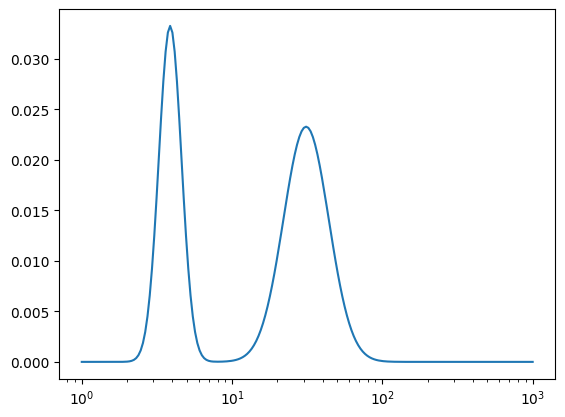

In [4]:
plt.plot(T,x)
plt.xscale('log')

In [5]:
M = 50
tmin, tmax = 0,1.5
t = np.array([tmin + (tmax - tmin)*i/(M-1) for i in range(M)])
K = np.exp(-np.outer(t,T))

In [6]:
z = K@x.x
sigma = 0.01 * z[0]
w = np.random.normal(loc=np.zeros(M), scale=sigma,size=(M,))
y = z + w

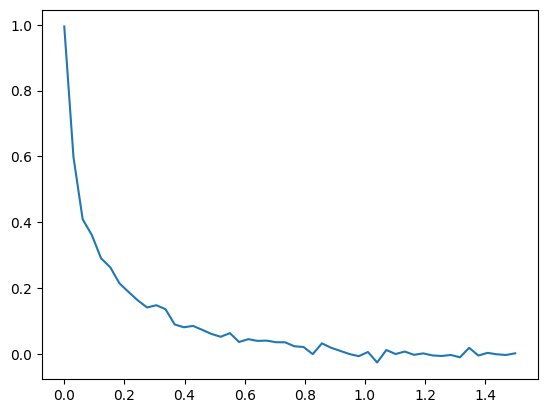

In [7]:
plt.plot(t, y)

Smootheness prior + constraint :

Best beta: 12.915496650148826
Minimum NQE: 10772.737512218417


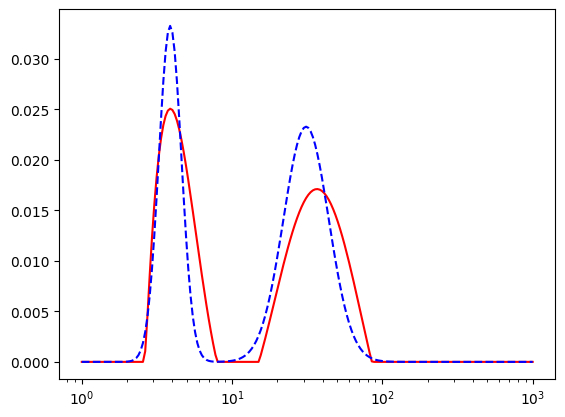

In [8]:
def g(x,x_min,x_max):
    init_val = 0
    D = 0
    for i in range(len(x)):
        if x[i] < x_min:
            return np.inf
        elif x[i] > x_max:
            return np.inf
        else:
            D += (x[i]-init_val)**2
            init_val = x[i]
    return 0.5*D

def f(x):
    Kx = K @ x
    return np.sqrt(np.sum((Kx - y)**2))

from scipy.optimize import minimize
grid_beta = np.logspace(-2,2,10)
NQE_list = [] 


## Naive optimization
for beta in grid_beta:
    res = minimize(lambda x: f(x) + beta*g(x,0,1e3), x0=np.ones(N), method='L-BFGS-B', bounds=[(0,None)]*N)
    NQE = np.sum(((res.x - x.x)**2)/(x.x**2))
    NQE_list.append(NQE)

best_beta = grid_beta[np.argmin(NQE_list)]
res = minimize(lambda x: f(x) + best_beta*g(x,0,1e3), x0=np.ones(N), method='L-BFGS-B', bounds=[(0,None)]*N)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
plt.plot(T, res.x, label='Reconstructed', color='red')
plt.plot(T, x.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()


NQE Forward-Backward: 1.7665378222409586e+42


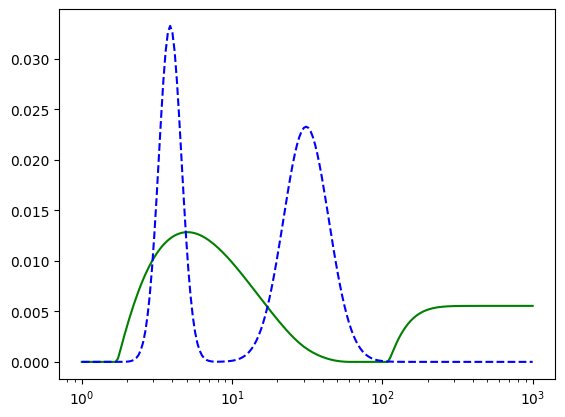

In [ ]:
## Forward - Backward optimization
import numpy as np
def proximal_g(v, gamma, xmin=0, xmax=1e3):
    """
    Solution du problème de minimisation
    (I/gamma + D^T D) x = v/gamma
    puis on projette sur [xmin, xmax].
    """
    N = len(v)
    main_diag = np.ones(N) * (1.0/gamma + 2.0)
    main_diag[0]  = 1.0/gamma + 1.0
    main_diag[-1] = 1.0/gamma + 1.0

    off_diag = np.ones(N-1) * (-1.0)
    b = v / gamma
    x = np.linalg.solve(np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1), b)
    x = np.clip(x, xmin, xmax)
    return x

def prox_f(v, gamma, K, y):
    A = K.T @ K + (1.0 / gamma) * np.eye(K.shape[1])
    rhs = K.T @ y + (1.0 / gamma) * v
    x = np.linalg.solve(A, rhs)
    return x

def forward_backward_optimization(beta, x_init, K, y, max_iter=100):
    x_curr = x_init.copy()
    lipschitz_const = np.linalg.norm(K, ord=2)**2
    gamma = 1 / lipschitz_const
    lambda_curr = 1

    for _ in range(max_iter):
        # Forward
        y_curr = x_curr - gamma * (K.T @ (K @ x_curr - y))
        # Backward
        x_next = x_curr + lambda_curr * (proximal_g(y_curr, beta * gamma) - x_curr)

        x_curr = x_next

    return x_curr

res_fb = forward_backward_optimization(10, np.ones(N), K, y, max_iter=500)
NQE_fb = np.sum(((res_fb - x.x)**2)/(x.x**2))
print("NQE Forward-Backward:", NQE_fb) 
plt.plot(T, res_fb, label='Reconstructed FB', color='green')
plt.plot(T, x.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

fin


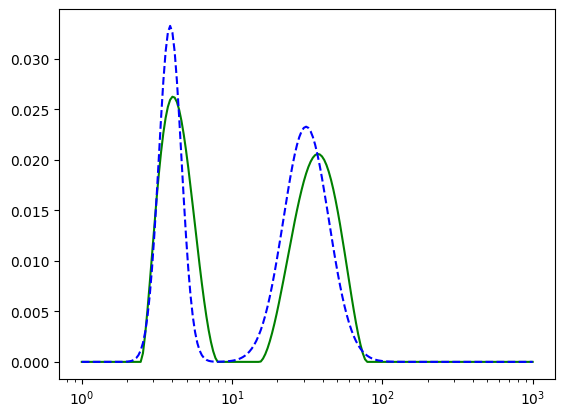

In [18]:
def douglas_rachford(K, y, beta, x0, gamma, n_iter=200, lamb=1, tol=1e-6):
    xn = x0.copy()
    for n in range(n_iter):      
        tau = gamma * beta
        yn = proximal_g(xn, tau)

        arg = 2.0 * yn - xn
        zn = prox_f(arg, gamma, K, y)

        xn1 = xn + lamb * (zn - yn)

        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            break

        xn = xn1

    x_est = np.clip(proximal_g(xn, tau), 0, 1000)  
    return x_est

x0 = np.zeros(N)
x_sol = douglas_rachford(K, y, beta = 1, x0 = x0, gamma = 1, n_iter=200, lamb = 1, tol=1e-6) 
print("fin")

plt.plot(T, x_sol, label='Reconstructed D-R', color='green')
plt.plot(T, x.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()
